# E-commerce Lifecycle Analytics  
## Notebook 4: Customer Segmentation

This notebook focuses on **customer segmentation** using user-level behavioural data.

Customer segmentation helps group users based on how they interact with the platform. Instead of treating all users the same, segmentation makes it easier to identify patterns such as casual browsers, engaged users, cart users, and purchasers.

### Objectives

- Build user-level behavioural metrics
- Segment users based on activity, engagement, and purchase behaviour
- Compare the size of each user segment
- Analyze behavioural differences across segments
- Generate business insights that can support product and marketing decisions

### Why this matters

Customer segmentation is a key part of lifecycle analytics because it helps businesses understand:

- which users are only browsing
- which users show buying intent
- which users are most valuable

These insights can support personalization, retention strategies, and conversion improvement initiatives.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
# Load cleaned dataset from previous notebook

df = pd.read_csv("Data /ecommerce_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1999840, 21)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_day,event_month,event_year,event_hour,day_of_week,year_month,year_week,is_weekend,price_band,main_category,sub_category
0,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,unknown_category,peda,"1,647.40",532353313,47059489-3a63-4353-9eab-0e239d5cb5aa,2019-10-09,9,10,2019,2,Wednesday,2019-10,2019-40,0,1000+,unknown_category,unknown
1,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e,2019-10-21,21,10,2019,16,Monday,2019-10,2019-42,0,100-250,electronics,video
2,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3,2019-10-21,21,10,2019,14,Monday,2019-10,2019-42,0,250-500,electronics,smartphone
3,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c,2019-10-03,3,10,2019,18,Thursday,2019-10,2019-39,0,50-100,auto,accessories
4,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,unknown_category,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b,2019-10-19,19,10,2019,8,Saturday,2019-10,2019-41,1,0-50,unknown_category,unknown


## 1. Dataset Overview

Before building customer segments, we first review the dataset structure and prepare the fields needed for user-level analysis.

Customer segmentation is performed at the **user level**, so the event-level dataset must be aggregated into user behaviour metrics.

In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (1999840, 21)

Columns:
 ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session', 'event_date', 'event_day', 'event_month', 'event_year', 'event_hour', 'day_of_week', 'year_month', 'year_week', 'is_weekend', 'price_band', 'main_category', 'sub_category']


In [4]:
# Convert event_time to datetime format
df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

# Create event_date for time-based summaries if needed later
df["event_date"] = df["event_time"].dt.date

df[["user_id", "event_type", "event_time", "user_session"]].head()

,user_id,event_type,event_time,user_session
0,532353313,view,2019-10-09 02:46:19+00:00,47059489-3a63-4353-9eab-0e239d5cb5aa
1,536042235,view,2019-10-21 16:17:11+00:00,a65ee34b-7701-4b25-95e7-45a1259e747e
2,517143806,cart,2019-10-21 14:42:20+00:00,a9ba13a7-afac-41ca-a3bc-016c580908c3
3,556492770,view,2019-10-03 18:40:22+00:00,799d5c0a-e1f3-4f22-b61d-ab78cfed068c
4,561838859,view,2019-10-19 08:58:51+00:00,dd474f7f-0559-41f5-8be0-9d0912cf2b1b


## 2. Analytical Approach

To create customer segments, we summarize event-level activity into user-level behavioural features.

Each user may have multiple actions such as:

- viewing products
- adding products to cart
- making purchases
- interacting across multiple sessions

We convert these interactions into behavioural metrics that describe:

- how active the user is
- how engaged the user is
- whether the user shows purchase intent
- whether the user has converted

## 3. Building User-Level Features

In this section, we create user-level features that summarize how each user behaves on the platform.

The features include:

- total events
- number of sessions
- number of views
- number of cart additions
- number of purchases
- number of active days
- average events per session

These metrics form the foundation for customer segmentation.

In [5]:
# Count total number of events generated by each user

user_total_events = (
    df.groupby("user_id")
      .size()
      .reset_index(name="total_events")
)

user_total_events.head()

,user_id,total_events
0,195082191,1
1,219406386,1
2,228761834,1
3,239475080,1
4,239876607,1


In [6]:
# Count unique sessions per user

user_sessions = (
    df.groupby("user_id")["user_session"]
      .nunique()
      .reset_index(name="total_sessions")
)

user_sessions.head()

,user_id,total_sessions
0,195082191,1
1,219406386,1
2,228761834,1
3,239475080,1
4,239876607,1


In [7]:
# Count number of active days per user

user_active_days = (
    df.groupby("user_id")["event_date"]
      .nunique()
      .reset_index(name="active_days")
)

user_active_days.head()

,user_id,active_days
0,195082191,1
1,219406386,1
2,228761834,1
3,239475080,1
4,239876607,1


In [8]:
# Count user activity by event type
# This shows how many views, carts, and purchases each user generated

user_event_type_counts = (
    df.pivot_table(
        index="user_id",
        columns="event_type",
        values="product_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

user_event_type_counts.head()

event_type,user_id,cart,purchase,view
0,195082191,0,0,1
1,219406386,0,0,1
2,228761834,0,0,1
3,239475080,0,0,1
4,239876607,0,0,1


In [9]:
# Rename event columns for clarity
# Some datasets may not contain all event types, so we handle that safely

user_event_type_counts = user_event_type_counts.rename(columns={
    "view": "view_events",
    "cart": "cart_events",
    "purchase": "purchase_events"
})

# Ensure expected columns exist even if one event type is missing
for col in ["view_events", "cart_events", "purchase_events"]:
    if col not in user_event_type_counts.columns:
        user_event_type_counts[col] = 0

user_event_type_counts.head()

event_type,user_id,cart_events,purchase_events,view_events
0,195082191,0,0,1
1,219406386,0,0,1
2,228761834,0,0,1
3,239475080,0,0,1
4,239876607,0,0,1


In [10]:
# Merge all user-level features into one dataframe

user_features = (
    user_total_events
    .merge(user_sessions, on="user_id", how="left")
    .merge(user_active_days, on="user_id", how="left")
    .merge(user_event_type_counts, on="user_id", how="left")
)

user_features.head()

,user_id,total_events,total_sessions,active_days,cart_events,purchase_events,view_events
0,195082191,1,1,1,0,0,1
1,219406386,1,1,1,0,0,1
2,228761834,1,1,1,0,0,1
3,239475080,1,1,1,0,0,1
4,239876607,1,1,1,0,0,1


In [11]:
# Create additional behavioural metrics

user_features["avg_events_per_session"] = (
    user_features["total_events"] / user_features["total_sessions"]
)

user_features["cart_rate"] = (
    user_features["cart_events"] / user_features["total_events"]
)

user_features["purchase_rate"] = (
    user_features["purchase_events"] / user_features["total_events"]
)

user_features["view_rate"] = (
    user_features["view_events"] / user_features["total_events"]
)

user_features.head()

,user_id,total_events,total_sessions,active_days,cart_events,purchase_events,view_events,avg_events_per_session,cart_rate,purchase_rate,view_rate
0,195082191,1,1,1,0,0,1,1.00,0.00,0.00,1.00
1,219406386,1,1,1,0,0,1,1.00,0.00,0.00,1.00
2,228761834,1,1,1,0,0,1,1.00,0.00,0.00,1.00
3,239475080,1,1,1,0,0,1,1.00,0.00,0.00,1.00
4,239876607,1,1,1,0,0,1,1.00,0.00,0.00,1.00


## 4. Reviewing User-Level Features

Now that the user-level dataset is ready, we review the behavioural metrics before assigning segments.

These features help us distinguish between:

- users who only browse
- users who engage more deeply
- users who add items to cart
- users who complete purchases

In [12]:
user_features.describe()

,user_id,total_events,total_sessions,active_days,cart_events,purchase_events,view_events,avg_events_per_session,cart_rate,purchase_rate,view_rate
count,"935,717.00","935,717.00","935,717.00","935,717.00","935,717.00","935,717.00","935,717.00","935,717.00","935,717.00","935,717.00","935,717.00"
mean,"536,059,709.14",2.14,1.68,1.51,0.05,0.04,2.05,1.23,0.02,0.02,0.96
std,"18,992,767.73",2.56,1.65,1.14,0.25,0.22,2.51,0.52,0.13,0.11,0.17
min,"195,082,191.00",1.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
25%,"517,337,191.00",1.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00
50%,"535,545,342.00",1.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00
75%,"555,153,188.00",2.00,2.00,2.00,0.00,0.00,2.00,1.00,0.00,0.00,1.00
max,"566,280,392.00",328.00,328.00,31.00,18.00,20.00,328.00,27.00,1.00,1.00,1.00


## 5. Defining Customer Segments

We now assign users into simple rule-based behavioural segments.

### Segment definitions

- **Purchasers**: users with at least one purchase event
- **Cart Users**: users with cart activity but no purchase
- **Engaged Browsers**: users with high browsing/session activity but no cart or purchase
- **Casual Browsers**: users with low browsing activity and no deeper conversion signals

This rule-based approach is easy to interpret and works well for business-facing analytics projects.

In [13]:
# Define segmentation logic using behavioural rules

def assign_segment(row):
    if row["purchase_events"] > 0:
        return "Purchasers"
    elif row["cart_events"] > 0:
        return "Cart Users"
    elif (row["total_events"] >= 5) or (row["total_sessions"] >= 2):
        return "Engaged Browsers"
    else:
        return "Casual Browsers"

user_features["customer_segment"] = user_features.apply(assign_segment, axis=1)

user_features.head()

,user_id,total_events,total_sessions,active_days,cart_events,purchase_events,view_events,avg_events_per_session,cart_rate,purchase_rate,view_rate,customer_segment
0,195082191,1,1,1,0,0,1,1.00,0.00,0.00,1.00,Casual Browsers
1,219406386,1,1,1,0,0,1,1.00,0.00,0.00,1.00,Casual Browsers
2,228761834,1,1,1,0,0,1,1.00,0.00,0.00,1.00,Casual Browsers
3,239475080,1,1,1,0,0,1,1.00,0.00,0.00,1.00,Casual Browsers
4,239876607,1,1,1,0,0,1,1.00,0.00,0.00,1.00,Casual Browsers


In [14]:
# Count users in each segment

segment_distribution = (
    user_features["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = ["customer_segment", "user_count"]

segment_distribution

,customer_segment,user_count
0,Casual Browsers,608551
1,Engaged Browsers,262266
2,Cart Users,33646
3,Purchasers,31254


In [15]:
# Calculate percentage share of each segment

segment_distribution["user_pct"] = (
    segment_distribution["user_count"] / segment_distribution["user_count"].sum() * 100
).round(2)

segment_distribution

,customer_segment,user_count,user_pct
0,Casual Browsers,608551,65.04
1,Engaged Browsers,262266,28.03
2,Cart Users,33646,3.60
3,Purchasers,31254,3.34


## 6. Segment Distribution

This section shows how users are distributed across the behavioural segments.

Understanding segment size helps answer questions such as:

- What share of users are only browsing?
- How many users show purchase intent?
- How large is the converting user base?

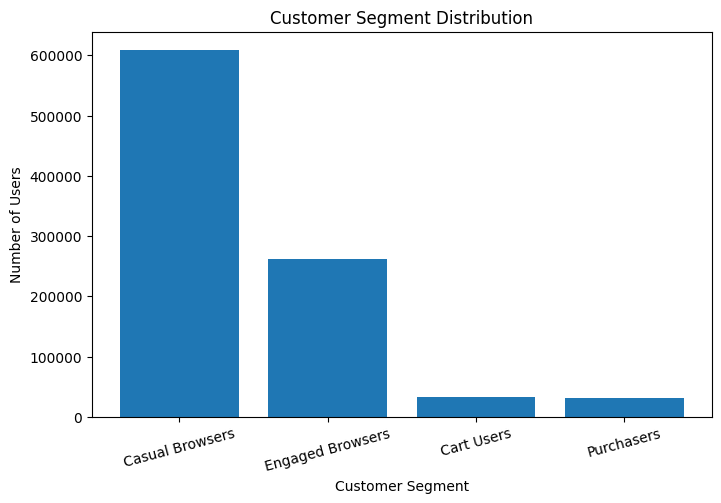

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_distribution["customer_segment"],
    segment_distribution["user_count"]
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=15)

plt.show()

## 7. Segment Behaviour Comparison

Beyond segment size, it is useful to compare how behaviour differs across segments.

In this section, we compare segments using metrics such as:

- average total events
- average sessions
- average active days
- average views, carts, and purchases

This helps explain how behaviour changes across the customer lifecycle.

In [18]:
segment_summary = (
    user_features.groupby("customer_segment")[
        [
            "total_events",
            "total_sessions",
            "active_days",
            "view_events",
            "cart_events",
            "purchase_events",
            "avg_events_per_session"
        ]
    ]
    .mean()
    .round(2)
    .reset_index()
)

segment_summary

,customer_segment,total_events,total_sessions,active_days,view_events,cart_events,purchase_events,avg_events_per_session
0,Cart Users,3.24,2.45,2.02,2.13,1.11,0.00,1.31
1,Casual Browsers,1.18,1.00,1.00,1.18,0.00,0.00,1.18
2,Engaged Browsers,4.01,3.02,2.51,4.01,0.00,0.00,1.32
3,Purchasers,3.90,2.96,2.35,2.58,0.20,1.13,1.30


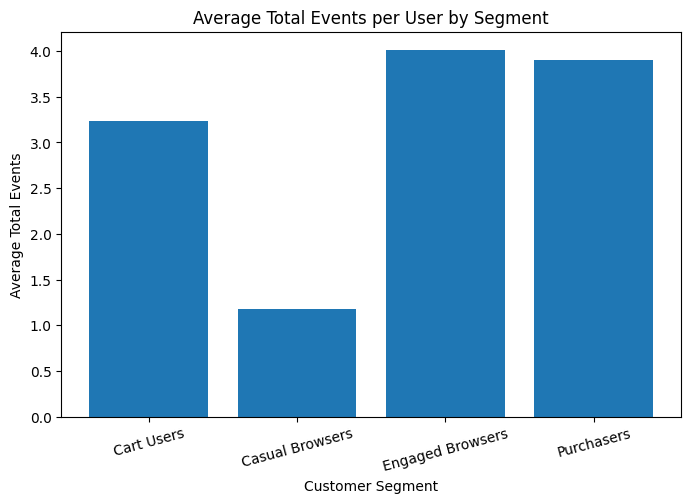

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary["customer_segment"],
    segment_summary["total_events"]
)

plt.title("Average Total Events per User by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Total Events")
plt.xticks(rotation=15)

plt.show()

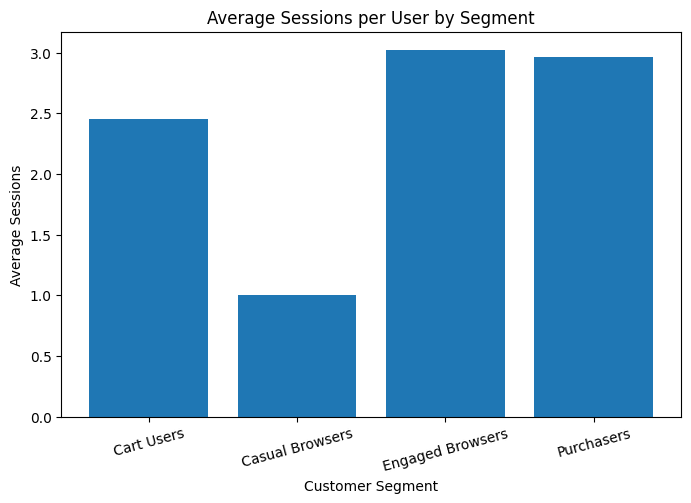

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary["customer_segment"],
    segment_summary["total_sessions"]
)

plt.title("Average Sessions per User by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sessions")
plt.xticks(rotation=15)

plt.show()

In [21]:
# Check conversion-oriented behaviour by segment

purchase_behaviour_summary = (
    user_features.groupby("customer_segment")[
        ["view_events", "cart_events", "purchase_events"]
    ]
    .mean()
    .round(2)
    .reset_index()
)

purchase_behaviour_summary

,customer_segment,view_events,cart_events,purchase_events
0,Cart Users,2.13,1.11,0.00
1,Casual Browsers,1.18,0.00,0.00
2,Engaged Browsers,4.01,0.00,0.00
3,Purchasers,2.58,0.20,1.13


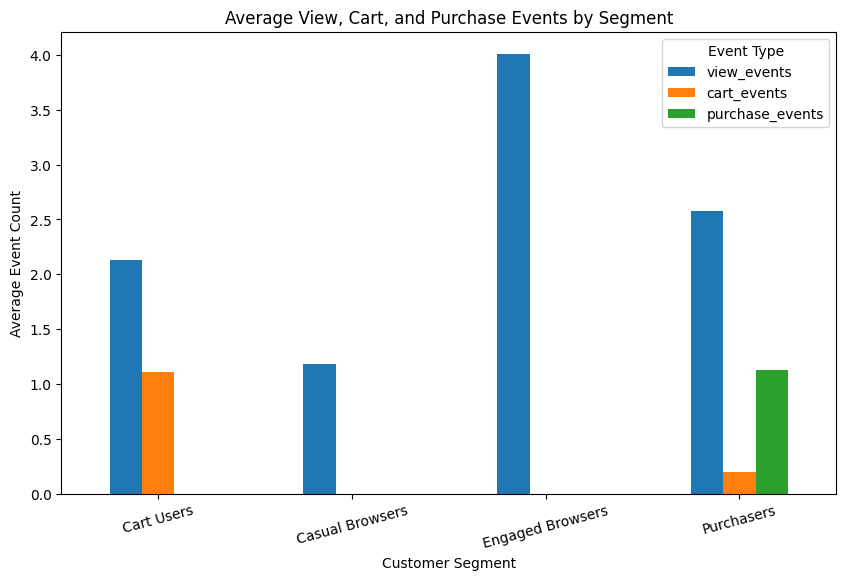

In [22]:
# Create a grouped bar-style comparison using separate bars

purchase_plot = purchase_behaviour_summary.set_index("customer_segment")

purchase_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average View, Cart, and Purchase Events by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Event Count")
plt.xticks(rotation=15)
plt.legend(title="Event Type")

plt.show()

## 8. Identifying Higher-Value Users

Purchasers are generally the most valuable segment because they generate completed transactions.

However, cart users also represent an important opportunity because they show strong purchase intent but have not yet converted.

This section provides a simple view of users who are closest to conversion.

In [23]:
high_intent_users = user_features[
    user_features["customer_segment"].isin(["Cart Users", "Purchasers"])
]

high_intent_summary = (
    high_intent_users["customer_segment"]
    .value_counts()
    .reset_index()
)

high_intent_summary.columns = ["customer_segment", "user_count"]

high_intent_summary

,customer_segment,user_count
0,Cart Users,33646
1,Purchasers,31254


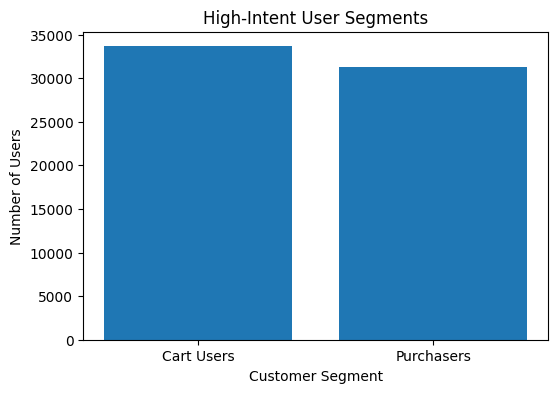

In [24]:
plt.figure(figsize=(6, 4))

plt.bar(
    high_intent_summary["customer_segment"],
    high_intent_summary["user_count"]
)

plt.title("High-Intent User Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Users")

plt.show()

## 9. Final Insights

The customer segmentation analysis provides a detailed view of how users interact with the platform across different stages of the customer journey.

### Browsing Dominates User Behaviour
The majority of users fall into the **Casual Browsers segment**, representing **65.04% of all users**. These users typically generate only a small number of interactions, with an average of **1.18 events and 1 session per user**, indicating that most users visit the platform briefly without deeper engagement.

### Engaged Browsers Show Higher Interaction
The **Engaged Browsers segment accounts for 28.03% of users** and demonstrates significantly higher interaction levels. These users generate an average of **4 events and 3 sessions per user**, suggesting deeper exploration of the product catalogue even though they do not yet progress toward cart or purchase activity.

### Purchase Intent is Concentrated in a Small Segment
Only **3.60% of users fall into the Cart Users segment**, meaning relatively few users progress from browsing to showing purchase intent. Cart users typically generate more sessions and interactions than casual users, reflecting stronger interest in products.

### Converting Users
The **Purchasers segment represents 3.34% of users**, highlighting the final stage of the customer journey. These users demonstrate higher activity levels and complete an average of **1.13 purchases per user**, indicating successful conversion after browsing and engagement.

### Customer Journey Perspective
The segmentation results reflect a typical e-commerce behavioural funnel:

Casual Browsers → Engaged Browsers → Cart Users → Purchasers

The large drop-off between browsing segments and purchase-oriented segments suggests that most users explore products but only a small share progress to purchase behaviour.

## 10. Business Takeaway

Customer segmentation helps translate raw behavioural data into actionable insights about how users interact with the platform.

The analysis shows that while a large portion of users browse products, only a small percentage progress to cart activity or purchase. This indicates that the biggest opportunity for growth lies in improving the transition from browsing behaviour to purchase intent.

Several potential strategies emerge from this analysis:

- **Improve product discovery for browsers**  
  Since most users remain in browsing segments, better product recommendations, search optimization, and personalized content could help increase engagement.

- **Encourage conversion among engaged users**  
  Engaged Browsers represent a large and active segment. Targeted promotions, personalized offers, or improved product comparisons may help move these users toward cart activity.

- **Reduce friction in the purchase journey**  
  Cart Users represent strong purchase intent but have not yet converted. Checkout simplification, reminders, or limited-time discounts could help convert these users into purchasers.

- **Retain high-value users**  
  Purchasers are the most valuable segment and may benefit from loyalty programs, personalized recommendations, or retention campaigns designed to encourage repeat purchases.

Overall, segmentation highlights where users are in the customer lifecycle and helps identify opportunities to improve engagement, conversion, and long-term customer value.

In [26]:
# Save user-level segmentation dataset for future analysis or dashboarding

user_features.to_csv("Data /customer_segmentation_output.csv", index=False)

print("Customer segmentation dataset exported successfully.")

Customer segmentation dataset exported successfully.
